# Phase 2 – Unsupervised Learning, Feature Engineering, and Interpretation

## Division of Labour
This section (Unsupervised Learning, Feature Engineering, and Interpretation) was completed by Shengwen Xu (40023262).

## Phase 2 Objective
This notebook focuses on the unsupervised learning component of Phase 2 in the COMP 333 final project.  
The goal is to identify meaningful trip patterns in the NYC TLC High Volume For-Hire Vehicles (HVFHV) dataset using clustering and dimensionality reduction, supported by feature engineering and interpretation.

## Response to Phase 1 Feedback
Compared with Phase 1, this notebook improves the analysis in the following ways:
- time-based information from `pickup_datetime` is incorporated into the clustering analysis
- clustering quality is evaluated using cluster-specific metrics
- a new engineered feature is added to better represent trip behavior
- final analytical claims are not based only on a small sample, but are developed on larger data and checked again on the full cleaned dataset

## Dataset Usage Strategy
To balance reproducibility, computational feasibility, and analytical rigor, this notebook uses multiple dataset scales for different stages of the workflow:
- `100k sample dataset`: used for debugging and lightweight code development
- `5M dataset`: used for the main unsupervised workflow
- `300k analysis subset drawn from the 5M dataset`: used for computationally expensive steps such as cluster selection, PCA, and KMeans fitting
- `full cleaned dataset`: used for final validation and interpretation

This design keeps development efficient while ensuring that the final conclusions remain grounded in large-scale data.

In [2]:
from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## Data Loading and Environment Setup

In this section, the processed dataset is loaded and prepared for Phase 2 analysis.

The notebook supports multiple dataset scales because different stages of the workflow have different computational requirements:
- the `100k sample dataset` is used for debugging and rapid iteration
- the `5M dataset` is used for the main unsupervised analysis workflow
- a large analysis subset drawn from the `5M dataset` is used for computationally expensive clustering steps
- the `full cleaned dataset` is reserved for final validation and interpretation

This strategy is intended to address the Phase 1 feedback appropriately: smaller datasets may be used during iterative development, but the final analytical claims should be supported by large-scale data and validated on the full cleaned dataset whenever possible.

In [3]:
# ==============================
# Dataset Configuration
# ==============================
DATA_MODE = "eda_5m"   # options: "sample", "eda_5m", "full"

# Project path
PROJECT_DIR = Path.cwd()

FULL_DATA_PATH = PROJECT_DIR / "tripdata_clean_full.parquet"
EDA_5M_PATH = PROJECT_DIR / "tripdata_clean_eda_5M.parquet"
SAMPLE_DATA_PATH = PROJECT_DIR / "tripdata_sample_100k.parquet"

print("Current project directory:", PROJECT_DIR)
print("Full dataset exists:", FULL_DATA_PATH.exists())
print("5M dataset exists:", EDA_5M_PATH.exists())
print("100k sample dataset exists:", SAMPLE_DATA_PATH.exists())

# ==============================
# Select dataset
# ==============================
if DATA_MODE == "full":
    DATA_PATH = FULL_DATA_PATH
    dataset_name = "full cleaned dataset"
elif DATA_MODE == "eda_5m":
    DATA_PATH = EDA_5M_PATH
    dataset_name = "5M EDA dataset"
elif DATA_MODE == "sample":
    DATA_PATH = SAMPLE_DATA_PATH
    dataset_name = "100k sample dataset"
else:
    raise ValueError("DATA_MODE must be one of: 'sample', 'eda_5m', or 'full'")

print(f"\nLoading {dataset_name}...")
print("Selected file:", DATA_PATH)

# Load the core columns required for clustering and feature engineering
columns_needed = [
    "hvfhs_license_num",
    "pickup_datetime",
    "trip_miles",
    "trip_time",
    "driver_pay"
]

df = pd.read_parquet(DATA_PATH, columns=columns_needed)

print("Loaded dataset shape:", df.shape)
print("Current DATA_MODE:", DATA_MODE)

df.head()

Current project directory: /Users/xsw/Desktop/MyProject/COMP333-Group Project
Full dataset exists: True
5M dataset exists: True
100k sample dataset exists: True

Loading 5M EDA dataset...
Selected file: /Users/xsw/Desktop/MyProject/COMP333-Group Project/tripdata_clean_eda_5M.parquet
Loaded dataset shape: (5000000, 5)
Current DATA_MODE: eda_5m


,hvfhs_license_num,pickup_datetime,trip_miles,trip_time,driver_pay
0,HV0003,2026-01-27 12:39:31,1.5900,1455,18.9100
1,HV0003,2026-01-01 16:42:50,1.1400,594,7.9300
2,HV0005,2026-01-18 16:20:38,3.7330,1991,26.5500
3,HV0003,2026-01-09 07:36:57,9.9000,1731,31.3000
4,HV0005,2025-12-16 11:51:36,2.7730,1413,19.4200


## Initial Inspection and Feature Planning

Before constructing clustering features, the selected dataset is briefly inspected to confirm data types, missing values, and the overall structure of the variables used in Phase 2.

This step is important for two reasons:
- it verifies that the selected columns are suitable for feature engineering and clustering
- it helps identify distributional properties, such as skewness and extreme values, that may influence preprocessing decisions

The planned clustering analysis focuses on both trip behavior and temporal characteristics.  
The feature space will therefore include:
- raw trip variables: `trip_miles`, `trip_time`, `driver_pay`
- time-based features derived from `pickup_datetime`
- one engineered behavioral feature: `speed_mph`

In [4]:
print("Inspection dataset mode:", DATA_MODE)
print("Dataset shape:", df.shape)

print("\nColumn data types:")
print(df.dtypes)

print("\nMissing values by column:")
print(df.isnull().sum())

print("\nSummary statistics:")
display(df[["trip_miles", "trip_time", "driver_pay"]].describe())

print("\nUnique provider codes:")
print(df["hvfhs_license_num"].value_counts())

print("\nPickup datetime range:")
print("Min:", df["pickup_datetime"].min())
print("Max:", df["pickup_datetime"].max())

Inspection dataset mode: eda_5m
Dataset shape: (5000000, 5)

Column data types:
hvfhs_license_num            object
pickup_datetime      datetime64[us]
trip_miles                  float32
trip_time                     int32
driver_pay                  float32
dtype: object

Missing values by column:
hvfhs_license_num    0
pickup_datetime      0
trip_miles           0
trip_time            0
driver_pay           0
dtype: int64

Summary statistics:


,trip_miles,trip_time,driver_pay
count,"5,000,000.0000","5,000,000.0000","5,000,000.0000"
mean,4.7471,"1,162.9038",20.6265
std,5.6469,841.3147,17.8669
min,0.0030,1.0000,-24.7000
25%,1.4300,575.0000,9.0800
50%,2.7520,940.0000,15.4600
75%,5.8900,"1,502.0000",26.1500
max,343.6000,"35,715.0000","1,197.2700"



Unique provider codes:
hvfhs_license_num
HV0003    3626656
HV0005    1373344
Name: count, dtype: int64

Pickup datetime range:
Min: 2025-12-01 00:00:00
Max: 2026-01-31 23:59:59


## Feature Engineering for Clustering

To improve the clustering analysis, new features are constructed from the original trip records.

This step is important because clustering depends heavily on how similarity is defined between observations.  
Using only raw variables such as trip distance and trip duration may overlook meaningful behavioral patterns in the data.

In this notebook, two types of engineered features are introduced:
- time-based features derived from `pickup_datetime`
- a domain-specific feature, `speed_mph`, to capture trip efficiency and traffic-related behavior

The same feature-engineering logic is intended to be applied consistently across dataset modes.

In [5]:
# Time-based features
df["pickup_hour"] = df["pickup_datetime"].dt.hour.astype("int8")
df["pickup_dayofweek"] = df["pickup_datetime"].dt.dayofweek.astype("int8")

# Domain-specific feature: average speed in miles per hour
df["speed_mph"] = (df["trip_miles"] / (df["trip_time"] / 3600)).astype("float32")

feature_cols_preview = [
    "pickup_datetime",
    "pickup_hour",
    "pickup_dayofweek",
    "trip_miles",
    "trip_time",
    "driver_pay",
    "speed_mph"
]

print(f"Preview of engineered features on {dataset_name}:")
display(df[feature_cols_preview].head())

print("\nSummary statistics for engineered features:")
display(df[["pickup_hour", "pickup_dayofweek", "speed_mph"]].describe())

Preview of engineered features on 5M EDA dataset:


,pickup_datetime,pickup_hour,pickup_dayofweek,trip_miles,trip_time,driver_pay,speed_mph
0,2026-01-27 12:39:31,12,1,1.5900,1455,18.9100,3.9340
1,2026-01-01 16:42:50,16,3,1.1400,594,7.9300,6.9091
2,2026-01-18 16:20:38,16,6,3.7330,1991,26.5500,6.7498
3,2026-01-09 07:36:57,7,4,9.9000,1731,31.3000,20.5893
4,2025-12-16 11:51:36,11,1,2.7730,1413,19.4200,7.0650



Summary statistics for engineered features:


,pickup_hour,pickup_dayofweek,speed_mph
count,"5,000,000.0000","5,000,000.0000","5,000,000.0000"
mean,13.4033,3.0579,13.0746
std,6.3907,1.9282,7.0819
min,0.0000,0.0000,0.0039
25%,9.0000,1.0000,8.3208
50%,14.0000,3.0000,11.0225
75%,19.0000,5.0000,15.8411
max,23.0000,6.0000,661.3260


## Preprocessing for Clustering

Before applying dimensionality reduction and clustering, the engineered features must be preprocessed carefully.

This step is necessary because clustering algorithms such as KMeans are highly sensitive to feature scale and extreme values.  
In particular, the variables `trip_miles`, `driver_pay`, and `speed_mph` show substantial right-skewness, and the summary statistics suggest the presence of extreme observations.

To improve clustering stability and interpretability, the following preprocessing steps are applied:
- remove extreme values in `speed_mph` using a data-driven threshold based on the 99th percentile
- apply log transformation to strongly right-skewed variables
- define the final feature set for clustering
- prepare the data for later standardization, PCA, and KMeans analysis

Negative values in `driver_pay` are retained at this stage because they may reflect valid platform adjustments, refunds, or other accounting corrections rather than simple data-entry errors.

In [6]:
# ------------------------------
# Remove extreme speed values using the 99th percentile
# ------------------------------
initial_rows = len(df)

speed_upper_bound = df["speed_mph"].quantile(0.99)
df = df[(df["speed_mph"] > 0) & (df["speed_mph"] <= speed_upper_bound)]

print("Preprocessing dataset mode:", DATA_MODE)
print("Rows before speed filtering:", initial_rows)
print("Rows after speed filtering :", len(df))
print("Rows removed               :", initial_rows - len(df))
print("99th percentile of speed_mph:", speed_upper_bound)

# ------------------------------
# Log-transform right-skewed variables
# ------------------------------
df["log_trip_miles"] = np.log1p(df["trip_miles"]).astype("float32")
df["log_driver_pay"] = np.log1p(df["driver_pay"]).astype("float32")
df["log_speed_mph"] = np.log1p(df["speed_mph"]).astype("float32")

# ------------------------------
# Final feature set for clustering
# ------------------------------
cluster_features = [
    "log_trip_miles",
    "trip_time",
    "log_driver_pay",
    "pickup_hour",
    "pickup_dayofweek",
    "log_speed_mph"
]

# Remove rows with missing values in the final clustering features
before_dropna = len(df)
df = df.dropna(subset=cluster_features)

print("\nRows before dropping NaNs in clustering features:", before_dropna)
print("Rows after dropping NaNs in clustering features :", len(df))
print("Rows removed due to NaNs                        :", before_dropna - len(df))

print("\nSelected clustering features:")
print(cluster_features)

print("\nSummary statistics after preprocessing:")
display(df[cluster_features].describe())


Preprocessing dataset mode: eda_5m
Rows before speed filtering: 5000000
Rows after speed filtering : 4950000
Rows removed               : 50000
99th percentile of speed_mph: 36.44776355743404

Rows before dropping NaNs in clustering features: 4950000
Rows after dropping NaNs in clustering features : 4949991
Rows removed due to NaNs                        : 9

Selected clustering features:
['log_trip_miles', 'trip_time', 'log_driver_pay', 'pickup_hour', 'pickup_dayofweek', 'log_speed_mph']

Summary statistics after preprocessing:


,log_trip_miles,trip_time,log_driver_pay,pickup_hour,pickup_dayofweek,log_speed_mph
count,"4,949,991.0000","4,949,991.0000","4,949,991.0000","4,949,991.0000","4,949,991.0000","4,949,991.0000"
mean,1.4392,"1,149.9248",2.8129,13.4221,3.0573,2.5235
std,0.6914,824.6453,0.6777,6.3691,1.9276,0.4459
min,0.0030,1.0000,0.0000,0.0000,0.0000,0.0039
25%,0.8838,572.0000,2.3046,9.0000,1.0000,2.2294
50%,1.3135,933.0000,2.7918,14.0000,3.0000,2.4817
75%,1.9066,"1,485.0000",3.2862,19.0000,5.0000,2.8095
max,5.4018,"35,715.0000",6.9515,23.0000,6.0000,3.6229


## Choosing the Number of Clusters

To determine a reasonable number of clusters for KMeans, several candidate values of `k` are compared using multiple evaluation metrics.

Because full cluster-search evaluation is computationally expensive on millions of records, this stage is performed on a large analysis subset drawn from the 5M dataset.  
This preserves the large-scale character of the analysis while keeping cluster selection computationally feasible.

Rather than selecting `k` arbitrarily, the analysis evaluates cluster quality using:
- inertia (within-cluster sum of squares)
- silhouette score
- Calinski-Harabasz score
- Davies-Bouldin score

These metrics provide complementary perspectives on cluster compactness and separation, helping identify a clustering solution that is both interpretable and well-formed.


In [7]:
# Create a large analysis subset for cluster selection
analysis_sample_size = 300_000

if len(df) > analysis_sample_size:
    df_ksearch = df.sample(n=analysis_sample_size, random_state=RANDOM_STATE)
else:
    df_ksearch = df

print("Cluster-selection dataset shape:", df_ksearch.shape)

# Standardize the clustering features on the analysis subset
X_ksearch = df_ksearch[cluster_features]

scaler_ksearch = StandardScaler()
X_ksearch_scaled = scaler_ksearch.fit_transform(X_ksearch)

# Evaluate candidate values of k
k_values = range(2, 9)
results = []

for k in k_values:
    print(f"Evaluating k = {k}...")
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(X_ksearch_scaled)

    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_ksearch_scaled, cluster_labels)
    calinski = calinski_harabasz_score(X_ksearch_scaled, cluster_labels)
    davies = davies_bouldin_score(X_ksearch_scaled, cluster_labels)

    results.append({
        "k": k,
        "inertia": inertia,
        "silhouette_score": silhouette,
        "calinski_harabasz_score": calinski,
        "davies_bouldin_score": davies
    })

cluster_eval_df = pd.DataFrame(results)

print("\nCluster evaluation results:")
display(cluster_eval_df)


Cluster-selection dataset shape: (300000, 11)
Evaluating k = 2...
Evaluating k = 3...
Evaluating k = 4...
Evaluating k = 5...
Evaluating k = 6...
Evaluating k = 7...
Evaluating k = 8...

Cluster evaluation results:


,k,inertia,silhouette_score,calinski_harabasz_score,davies_bouldin_score
0,2,"1,176,490.1728",0.3153,"158,991.4277",1.2823
1,3,"1,024,493.0600",0.2111,"113,544.4932",1.5835
2,4,"904,342.7849",0.2025,"99,038.8669",1.4664
3,5,"800,624.0949",0.2057,"93,617.5420",1.4687
4,6,"730,344.4822",0.2013,"87,874.1780",1.3965
5,7,"670,120.7974",0.2072,"84,302.7461",1.3379
6,8,"625,892.5988",0.2076,"80,393.5722",1.2717


## Scaling and Principal Component Analysis (PCA)

Before applying KMeans clustering, the selected features are standardized so that variables measured on different scales contribute more comparably to the distance calculations.

Principal Component Analysis (PCA) is then applied for two purposes:
- to reduce the dimensionality of the clustering feature space
- to support visualization of the underlying structure of the trips in a lower-dimensional space

PCA is appropriate in this context because the clustering feature set includes multiple correlated numerical variables, and a lower-dimensional representation can help reveal whether meaningful grouping patterns are present in the data.


In [8]:
# ------------------------------
# Standardize clustering features on the analysis subset
# ------------------------------
X_ksearch = df_ksearch[cluster_features]

scaler_ksearch = StandardScaler()
X_ksearch_scaled = scaler_ksearch.fit_transform(X_ksearch)

print("Scaled feature matrix shape:", X_ksearch_scaled.shape)

# ------------------------------
# Apply PCA
# ------------------------------
pca = PCA()
X_pca = pca.fit_transform(X_ksearch_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

pca_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained_variance))],
    "Explained Variance Ratio": explained_variance,
    "Cumulative Variance": cumulative_variance
})

print("\nPCA summary:")
display(pca_summary)


Scaled feature matrix shape: (300000, 6)

PCA summary:


,PC,Explained Variance Ratio,Cumulative Variance
0,PC1,0.5047,0.5047
1,PC2,0.1830,0.6877
2,PC3,0.1624,0.8501
3,PC4,0.1275,0.9776
4,PC5,0.0192,0.9967
5,PC6,0.0033,1.0000


## PCA Visualization

To better understand the structure of the feature space, the first two principal components are visualized.

Although PCA itself does not produce clusters, it provides a lower-dimensional representation of the data that can help reveal whether meaningful grouping patterns may exist.  
This visualization is also useful later for displaying cluster assignments after KMeans is applied.

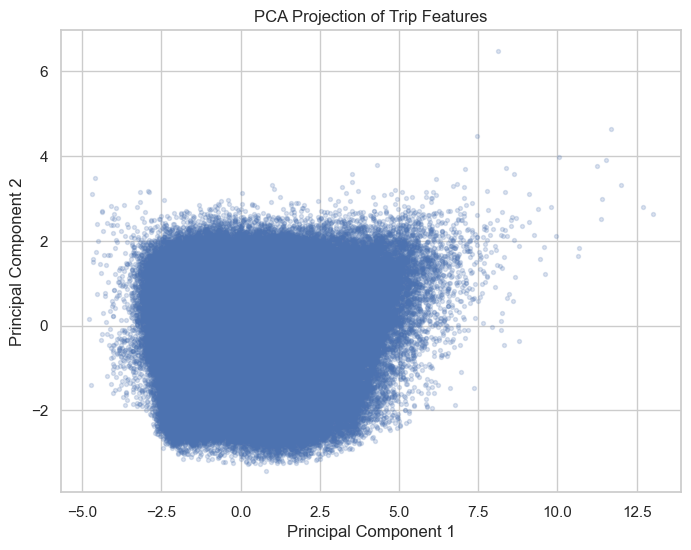

In [9]:
# Create a DataFrame for the first two principal components
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1]
})

# Scatter plot of the first two principal components
plt.figure(figsize=(8, 6))
plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.2,
    s=8
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Trip Features")
plt.show()


## Cluster Evaluation Plots

To compare the candidate values of `k` more clearly, the clustering evaluation metrics are visualized.

These plots help reveal:
- how within-cluster variation changes as the number of clusters increases
- whether there is an elbow-like pattern in inertia
- which values of `k` provide stronger cluster separation and compactness according to the other evaluation metrics

The goal is not to rely on a single metric alone, but to use multiple visual and quantitative criteria to support the final choice of `k`.

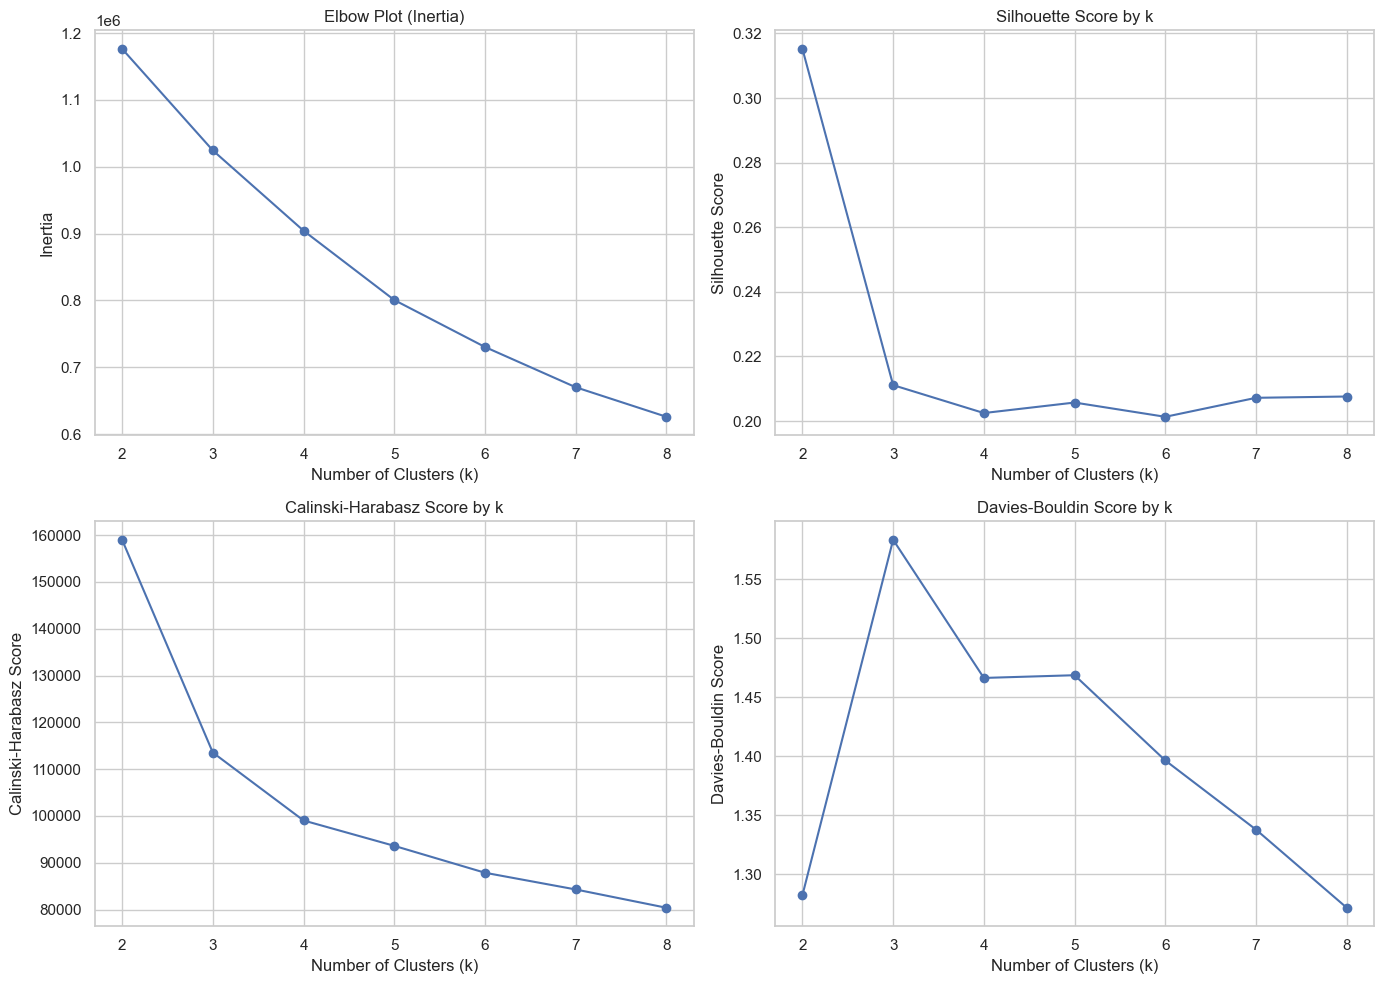

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Inertia
axes[0, 0].plot(cluster_eval_df["k"], cluster_eval_df["inertia"], marker="o")
axes[0, 0].set_title("Elbow Plot (Inertia)")
axes[0, 0].set_xlabel("Number of Clusters (k)")
axes[0, 0].set_ylabel("Inertia")

# Silhouette Score
axes[0, 1].plot(cluster_eval_df["k"], cluster_eval_df["silhouette_score"], marker="o")
axes[0, 1].set_title("Silhouette Score by k")
axes[0, 1].set_xlabel("Number of Clusters (k)")
axes[0, 1].set_ylabel("Silhouette Score")

# Calinski-Harabasz Score
axes[1, 0].plot(cluster_eval_df["k"], cluster_eval_df["calinski_harabasz_score"], marker="o")
axes[1, 0].set_title("Calinski-Harabasz Score by k")
axes[1, 0].set_xlabel("Number of Clusters (k)")
axes[1, 0].set_ylabel("Calinski-Harabasz Score")

# Davies-Bouldin Score
axes[1, 1].plot(cluster_eval_df["k"], cluster_eval_df["davies_bouldin_score"], marker="o")
axes[1, 1].set_title("Davies-Bouldin Score by k")
axes[1, 1].set_xlabel("Number of Clusters (k)")
axes[1, 1].set_ylabel("Davies-Bouldin Score")

plt.tight_layout()
plt.show()


## Selecting the Final Number of Clusters and Training KMeans

Based on the cluster evaluation metrics, a final value of `k` is selected for the KMeans model.

The chosen value of `k` is justified using multiple quality metrics rather than a single criterion alone.  
Although larger values of `k` may provide finer-grained segmentation, the selected solution offers the most stable and interpretable clustering structure in the current analysis subset drawn from the 5M dataset.

The final KMeans model is therefore trained on this large analysis subset, and the resulting cluster labels are used for visualization and interpretation.


In [11]:
# ------------------------------
# Train final KMeans model on the analysis subset
# ------------------------------
final_k = 2

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=RANDOM_STATE,
    n_init=10
)

df_ksearch["cluster"] = final_kmeans.fit_predict(X_ksearch_scaled)

print("Final number of clusters:", final_k)
print("\nCluster counts:")
print(df_ksearch["cluster"].value_counts().sort_index())


Final number of clusters: 2

Cluster counts:
cluster
0    190563
1    109437
Name: count, dtype: int64


## PCA Visualization of the Final Clusters

After selecting the final value of `k`, the cluster assignments are visualized in the space of the first two principal components.

This plot does not replace the clustering evaluation metrics, but it helps illustrate how the two clusters are distributed in a lower-dimensional representation of the feature space.  
It also provides an intuitive visual summary of how the trips are separated after applying KMeans.

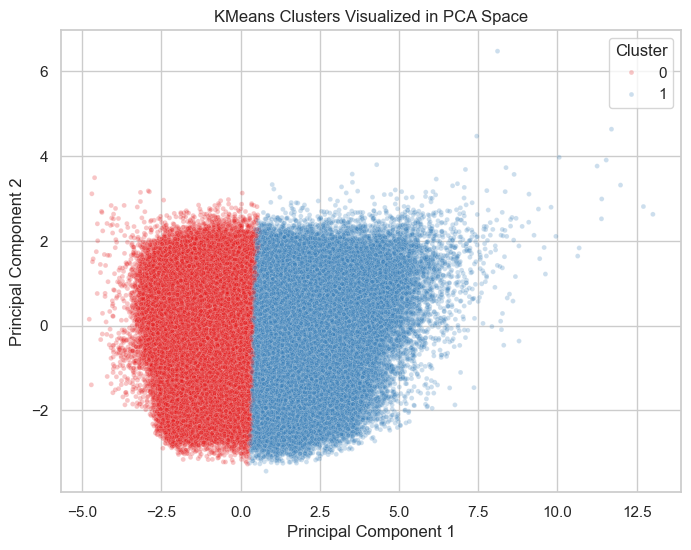

In [12]:
# Add cluster labels to the PCA DataFrame
pca_df["cluster"] = df_ksearch["cluster"].values

# Visualize the final clusters in PCA space
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set1",
    alpha=0.25,
    s=12
)

plt.title("KMeans Clusters Visualized in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()


## Cluster Profiling

To interpret the meaning of the final clusters, summary statistics are computed for each cluster.

This step helps translate the clustering output into more interpretable trip patterns by comparing the clusters in terms of:
- trip behavior (`trip_miles`, `trip_time`, `driver_pay`, `speed_mph`)
- temporal characteristics (`pickup_hour`, `pickup_dayofweek`)

By examining these differences, the clusters can be described in a more meaningful and domain-relevant way.

In [13]:
cluster_profile = df_ksearch.groupby("cluster")[
    [
        "trip_miles",
        "trip_time",
        "driver_pay",
        "speed_mph",
        "pickup_hour",
        "pickup_dayofweek"
    ]
].agg(["mean", "median", "std"])

print("Cluster profile summary:")
display(cluster_profile)


Cluster profile summary:


trip_miles                trip_time                     driver_pay  \
              mean median    std       mean     median      std       mean   
cluster                                                                      
0           1.8778 1.6900 0.9702   725.5330   663.0000 363.5264    11.5667   
1           9.0763 7.4000 5.4369 1,884.4227 1,682.0000 875.8771    34.8692   

                        speed_mph                pickup_hour                 \
         median     std      mean  median    std        mean  median    std   
cluster                                                                       
0       10.5400  5.9181    9.7910  9.3822 3.5938     13.6638 15.0000 6.2123   
1       29.9000 17.9962   18.0547 17.1200 7.1516     12.9779 14.0000 6.6499   

        pickup_dayofweek                
                    mean median    std  
cluster                                 
0                 3.0344 3.0000 1.9220  
1                 3.1016 3.0000 1.9295

## Standardized Cluster Profile Visualization

Because the clustering variables are measured on different scales, a direct comparison of raw mean values can be misleading.  
To make the cluster differences more interpretable, the feature means are standardized before visualization.

This plot highlights the relative profile of each cluster rather than the original magnitudes of the variables.

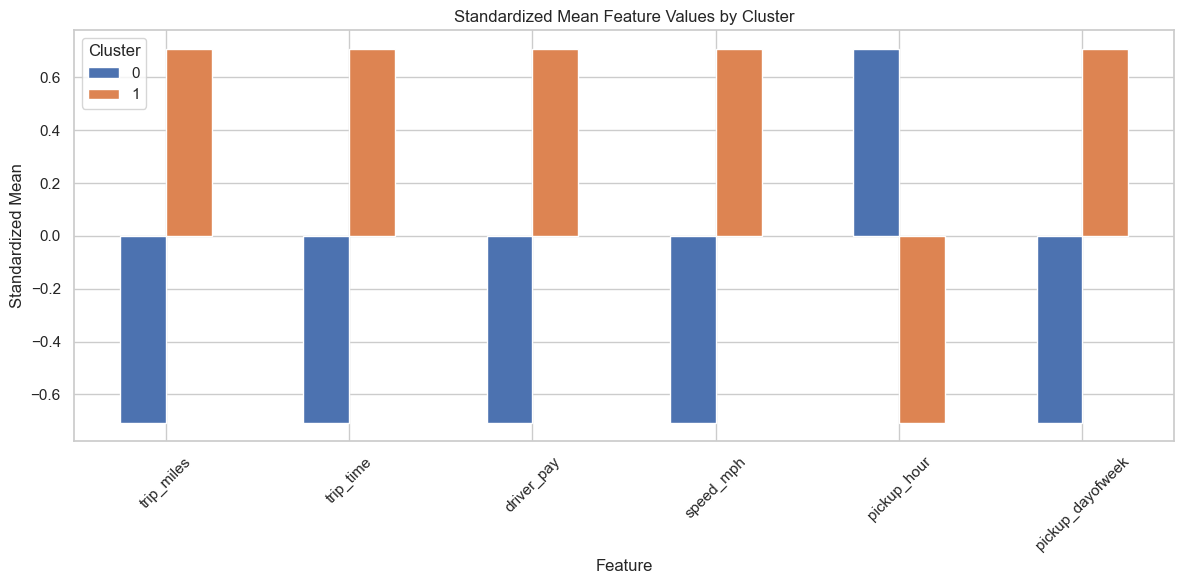

In [14]:
cluster_profile_means = df_ksearch.groupby("cluster")[
    ["trip_miles", "trip_time", "driver_pay", "speed_mph", "pickup_hour", "pickup_dayofweek"]
].mean()

# Standardize the cluster means column-wise
cluster_profile_standardized = (
    cluster_profile_means - cluster_profile_means.mean()
) / cluster_profile_means.std()

cluster_profile_standardized.T.plot(kind="bar", figsize=(12, 6))

plt.title("Standardized Mean Feature Values by Cluster")
plt.xlabel("Feature")
plt.ylabel("Standardized Mean")
plt.xticks(rotation=45)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


## Time Patterns by Cluster

To further interpret the role of temporal characteristics, the distribution of pickup hour is compared across clusters.

This analysis helps determine whether the identified trip patterns are associated with different times of day, which is particularly relevant for ride-share demand and trip behavior.

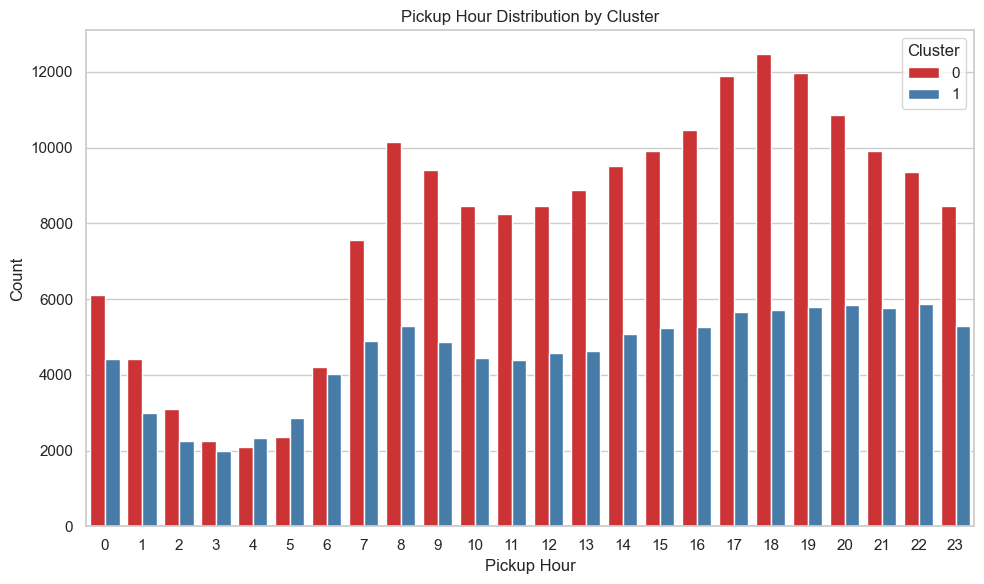

In [15]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_ksearch,
    x="pickup_hour",
    hue="cluster",
    palette="Set1"
)

plt.title("Pickup Hour Distribution by Cluster")
plt.xlabel("Pickup Hour")
plt.ylabel("Count")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


## Provider Distribution by Cluster

To further interpret the identified clusters, the distribution of service providers is examined across clusters.

Although `hvfhs_license_num` is not directly used as a clustering feature, it provides an important grouping variable for understanding whether the two trip patterns differ in their provider composition.

Provider distribution by cluster:


cluster,0,1
hvfhs_license_num,,
HV0003,136790,80548
HV0005,53773,28889


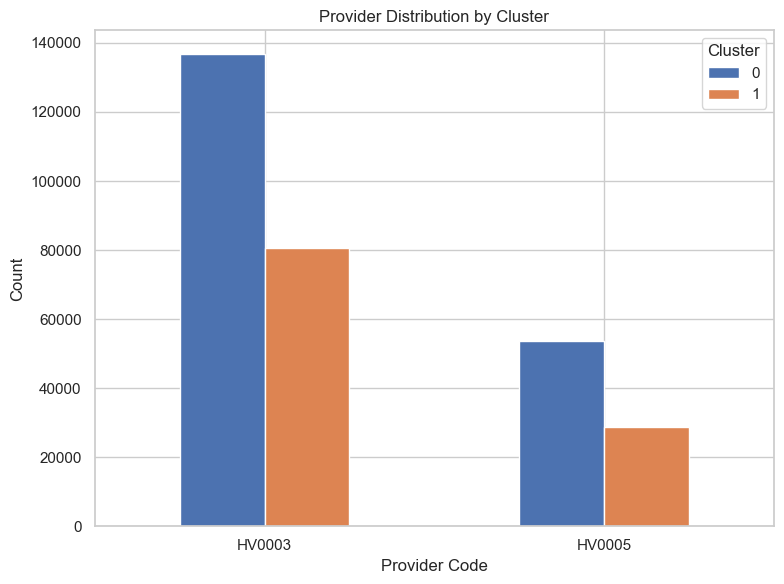

In [16]:
provider_cluster_counts = pd.crosstab(df_ksearch["hvfhs_license_num"], df_ksearch["cluster"])

print("Provider distribution by cluster:")
display(provider_cluster_counts)

provider_cluster_counts.plot(kind="bar", figsize=(8, 6))

plt.title("Provider Distribution by Cluster")
plt.xlabel("Provider Code")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


## Full-Dataset Validation

To validate the clustering results on the full cleaned dataset, the same preprocessing pipeline is applied to the full data and the clustering model learned from the 5M analysis workflow is used to assign cluster labels.

This approach allows the final cluster structure to be checked on the full dataset without repeating the computationally expensive cluster-search procedure.


In [17]:
# Reload the full cleaned dataset for final validation
full_columns_needed = [
    "hvfhs_license_num",
    "pickup_datetime",
    "trip_miles",
    "trip_time",
    "driver_pay"
]

df = pd.read_parquet(FULL_DATA_PATH, columns=full_columns_needed)

print("Reloaded full dataset shape:", df.shape)

# Re-apply feature engineering to the full dataset
df["pickup_hour"] = df["pickup_datetime"].dt.hour.astype("int8")
df["pickup_dayofweek"] = df["pickup_datetime"].dt.dayofweek.astype("int8")
df["speed_mph"] = (df["trip_miles"] / (df["trip_time"] / 3600)).astype("float32")

# Re-apply preprocessing to the full dataset
speed_upper_bound_full = df["speed_mph"].quantile(0.99)
df = df[(df["speed_mph"] > 0) & (df["speed_mph"] <= speed_upper_bound_full)]

df["log_trip_miles"] = np.log1p(df["trip_miles"]).astype("float32")
df["log_driver_pay"] = np.log1p(df["driver_pay"]).astype("float32")
df["log_speed_mph"] = np.log1p(df["speed_mph"]).astype("float32")

df = df.dropna(subset=cluster_features)

print("Full dataset shape after preprocessing:", df.shape)

# Apply the trained scaler and final KMeans model to the full dataset
X_full = df[cluster_features]
X_full_scaled = scaler_ksearch.transform(X_full)

df["cluster"] = final_kmeans.predict(X_full_scaled)

print("Full-dataset cluster counts:")
print(df["cluster"].value_counts().sort_index())


Reloaded full dataset shape: (43043669, 5)
Full dataset shape after preprocessing: (42613172, 11)
Full-dataset cluster counts:
cluster
0    27101389
1    15511783
Name: count, dtype: int64


## Full-Dataset Cluster Profiling

After assigning cluster labels to the full cleaned dataset, the cluster profiles are summarized to check whether the main trip-pattern differences observed in the 5M analysis workflow remain consistent at full scale.

In [18]:
cluster_profile_full = df.groupby("cluster")[
    [
        "trip_miles",
        "trip_time",
        "driver_pay",
        "speed_mph",
        "pickup_hour",
        "pickup_dayofweek"
    ]
].agg(["mean", "median", "std"])

print("Full-dataset cluster profile summary:")
display(cluster_profile_full)


Full-dataset cluster profile summary:


trip_miles                trip_time                     driver_pay  \
              mean median    std       mean     median      std       mean   
cluster                                                                      
0           1.8785 1.6900 0.9700   726.7635   665.0000 363.9702    11.5712   
1           9.1072 7.4200 5.4732 1,890.2201 1,690.0000 883.5941    34.9718   

                        speed_mph                pickup_hour                 \
         median     std      mean  median    std        mean  median    std   
cluster                                                                       
0       10.5500  5.9147    9.7793  9.3706 3.5911     13.6749 15.0000 6.1928   
1       29.9700 18.1946   18.0563 17.1328 7.1347     12.9764 14.0000 6.6439   

        pickup_dayofweek                
                    mean median    std  
cluster                                 
0                 3.0380 3.0000 1.9245  
1                 3.0894 3.0000 1.9324

## Full-Dataset Standardized Cluster Profiles

To compare the full-dataset cluster profiles more clearly across variables with different scales, the cluster means are standardized before visualization.


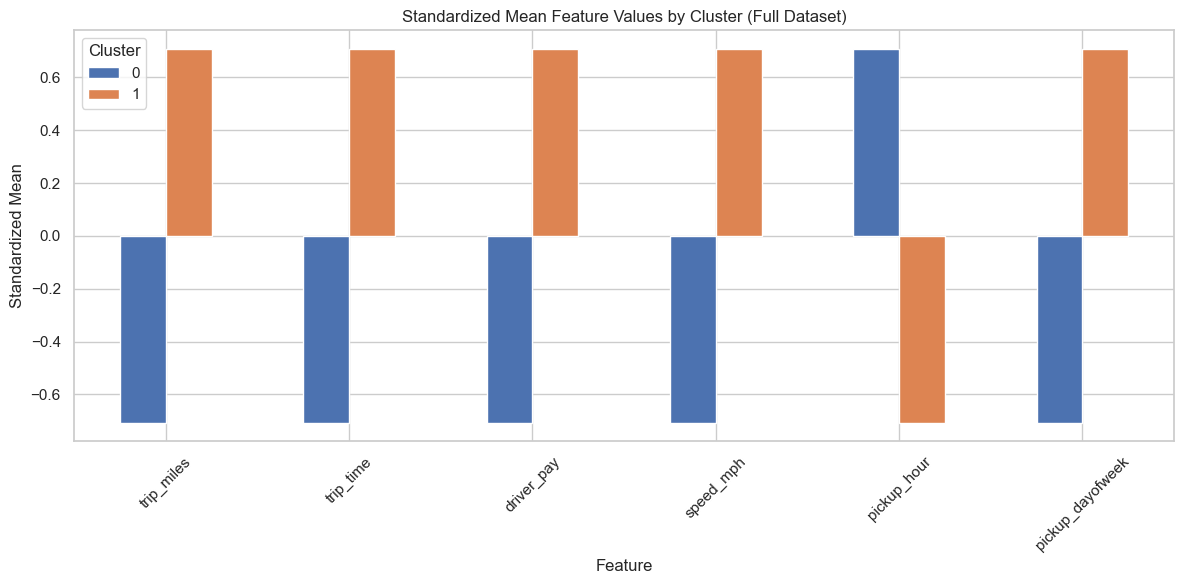

In [19]:
cluster_profile_means_full = df.groupby("cluster")[
    ["trip_miles", "trip_time", "driver_pay", "speed_mph", "pickup_hour", "pickup_dayofweek"]
].mean()

cluster_profile_standardized_full = (
    cluster_profile_means_full - cluster_profile_means_full.mean()
) / cluster_profile_means_full.std()

cluster_profile_standardized_full.T.plot(kind="bar", figsize=(12, 6))

plt.title("Standardized Mean Feature Values by Cluster (Full Dataset)")
plt.xlabel("Feature")
plt.ylabel("Standardized Mean")
plt.xticks(rotation=45)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


## Full-Dataset Time Patterns by Cluster

The pickup-hour distribution is examined on the full cleaned dataset to verify whether the temporal patterns observed in the 5M analysis workflow remain consistent at full scale.


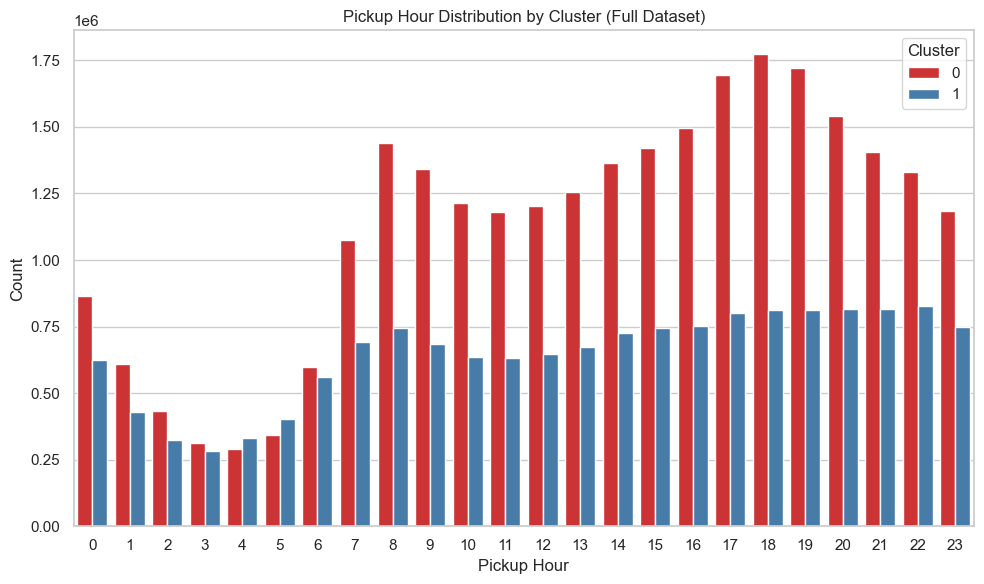

In [20]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="pickup_hour",
    hue="cluster",
    palette="Set1"
)

plt.title("Pickup Hour Distribution by Cluster (Full Dataset)")
plt.xlabel("Pickup Hour")
plt.ylabel("Count")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


## Full-Dataset Provider Distribution by Cluster

Finally, the distribution of service providers across clusters is checked on the full cleaned dataset to confirm whether the identified trip patterns remain present across both providers at full scale.


Full-dataset provider distribution by cluster:


cluster,0,1
hvfhs_license_num,,
HV0003,19445005,11456513
HV0005,7656384,4055270


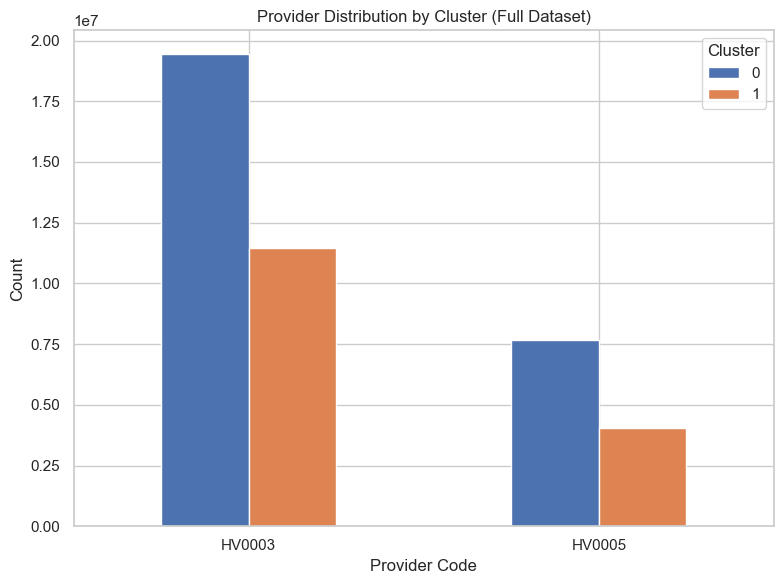

In [21]:
provider_cluster_counts_full = pd.crosstab(df["hvfhs_license_num"], df["cluster"])

print("Full-dataset provider distribution by cluster:")
display(provider_cluster_counts_full)

provider_cluster_counts_full.plot(kind="bar", figsize=(8, 6))

plt.title("Provider Distribution by Cluster (Full Dataset)")
plt.xlabel("Provider Code")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


## Interpretation

The clustering analysis identifies two main trip patterns in a large analysis subset drawn from the 5M dataset.

One cluster is characterized by longer trip distances, longer trip durations, higher driver pay, and higher average speed.  
This pattern is consistent with relatively larger and more efficient trips, which may include longer-distance or less congested rides.

The other cluster is characterized by shorter trip distances, shorter trip durations, lower driver pay, and lower average speed.  
This pattern is more consistent with shorter and lower-paying trips, likely representing more local or slower urban trips.

The temporal variables contribute some additional structure, but they are not the dominant source of separation.  
The pickup-hour distributions of the clusters are broadly similar, indicating that the cluster distinction is driven more strongly by trip characteristics than by time-of-day alone.

The provider analysis also shows that both `HV0003` and `HV0005` appear across the identified clusters.  
This suggests that the clustering is not simply separating providers, but rather capturing trip patterns that occur across both services.

The same workflow is then applied to the full cleaned dataset for validation.  
The full-dataset validation step is used to check whether the main trip-pattern differences observed in the 5M workflow remain consistent at full scale.

Overall, the results support the research objective by showing that HVFHV trips can be grouped into meaningful behavioral patterns using a combination of trip-level and time-based features.

### Conclusion

In this notebook, PCA and KMeans clustering were applied to engineered trip-level and temporal features in order to identify meaningful ride-share trip patterns.

The final clustering solution provides an interpretable structure in the current feature space.  
The identified clusters differ mainly in trip distance, duration, driver pay, and average speed, while temporal factors play a secondary role.

These findings suggest that unsupervised learning can reveal meaningful trip behavior patterns in the HVFHV dataset.  
The final validation on the full cleaned dataset strengthens the interpretation by checking whether the same overall cluster differences remain present at full scale.
